In [6]:
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from collections import Counter

# ── Load data ──────────────────────────────────────────────────────────────────
DATA_PATH = "../data/processed/survey_v1.1.json"

with open(DATA_PATH) as f:
    data = json.load(f)

N = len(data)
print(f"Loaded {N} records, {len(data[0])} fields each.")

# ── Shared style ───────────────────────────────────────────────────────────────
plt.rcParams.update({
    "figure.dpi": 130,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titlesize": 12,
    "axes.titleweight": "bold",
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
})

# Colour palette (one per section)
C_MEAS  = "#4C72B0"   # blue  – measures
C_BUILD = "#55A868"   # green – building
C_SOCIO = "#C44E52"   # red   – sociodemographics
C_TRIG  = "#DD8452"   # orange – triggers & subsidies

def pct_of(values, total=None):
    """Return list of percentages."""
    t = total or sum(values)
    return [v / t * 100 for v in values]

def get_field(field, cast=str):
    """Return non-null values of a field, cast to type."""
    return [cast(r[field]) for r in data if r.get(field) is not None]

Loaded 1651 records, 143 fields each.


---
## 4 · Triggers & Subsidies

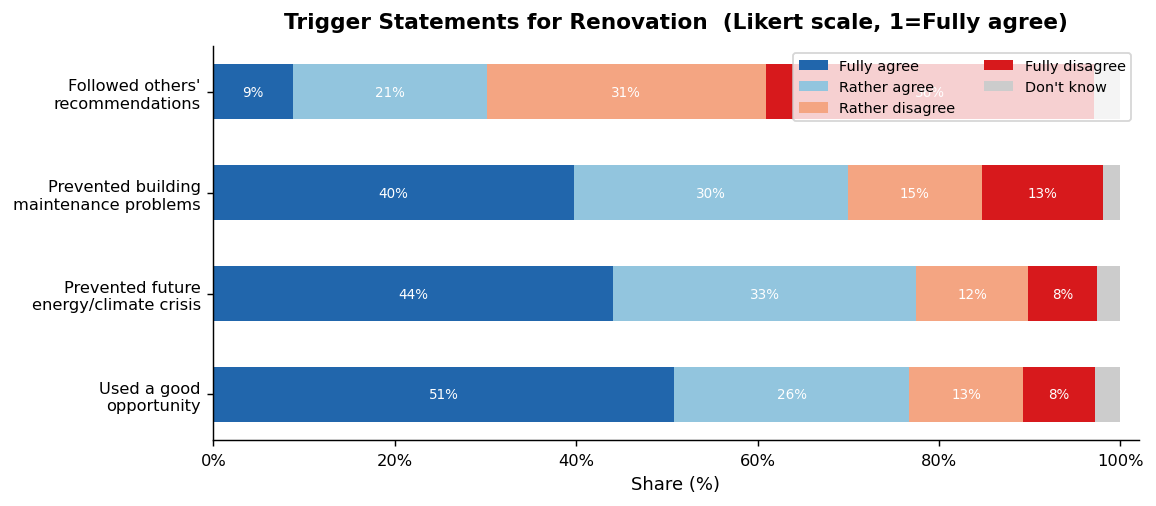

In [7]:
# ── 4a: Trigger statements — stacked Likert bar ───────────────────────────────
# Scale: 1=Fully agree, 2=Rather agree, 3=Rather disagree, 4=Fully disagree, 5=Don't know
trig_fields = ["TRIG_1", "TRIG_2", "TRIG_3", "TRIG_4"]
trig_labels = [
    "Used a good\nopportunity",
    "Prevented future\nenergy/climate crisis",
    "Prevented building\nmaintenance problems",
    "Followed others'\nrecommendations",
]
likert_labels  = ["Fully agree", "Rather agree", "Rather disagree", "Fully disagree", "Don't know"]
likert_colors  = ["#2166ac", "#92c5de", "#f4a582", "#d7191c", "#cccccc"]
likert_vals    = ["1", "2", "3", "4", "5"]

trig_data = {}
for field in trig_fields:
    vals  = get_field(field)
    total = len(vals)
    trig_data[field] = [vals.count(v) / total * 100 for v in likert_vals]

fig, ax = plt.subplots(figsize=(9, 4))
y_pos = np.arange(len(trig_fields))
left  = np.zeros(len(trig_fields))

for i, (lbl, color) in enumerate(zip(likert_labels, likert_colors)):
    widths = [trig_data[f][i] for f in trig_fields]
    bars   = ax.barh(y_pos, widths, left=left, color=color, height=0.55, label=lbl)
    for bar, w in zip(bars, widths):
        if w > 4:   # only label if wide enough
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_y() + bar.get_height() / 2,
                    f"{w:.0f}%", ha="center", va="center", fontsize=7.5, color="white")
    left += np.array(widths)

ax.set_yticks(y_pos)
ax.set_yticklabels(trig_labels, fontsize=9)
ax.set_xlabel("Share (%)")
ax.set_title("Trigger Statements for Renovation  (Likert scale, 1=Fully agree)", pad=10)
ax.xaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_xlim(0, 102)
ax.legend(loc="upper right", fontsize=8, ncol=2)
plt.tight_layout()
plt.show()

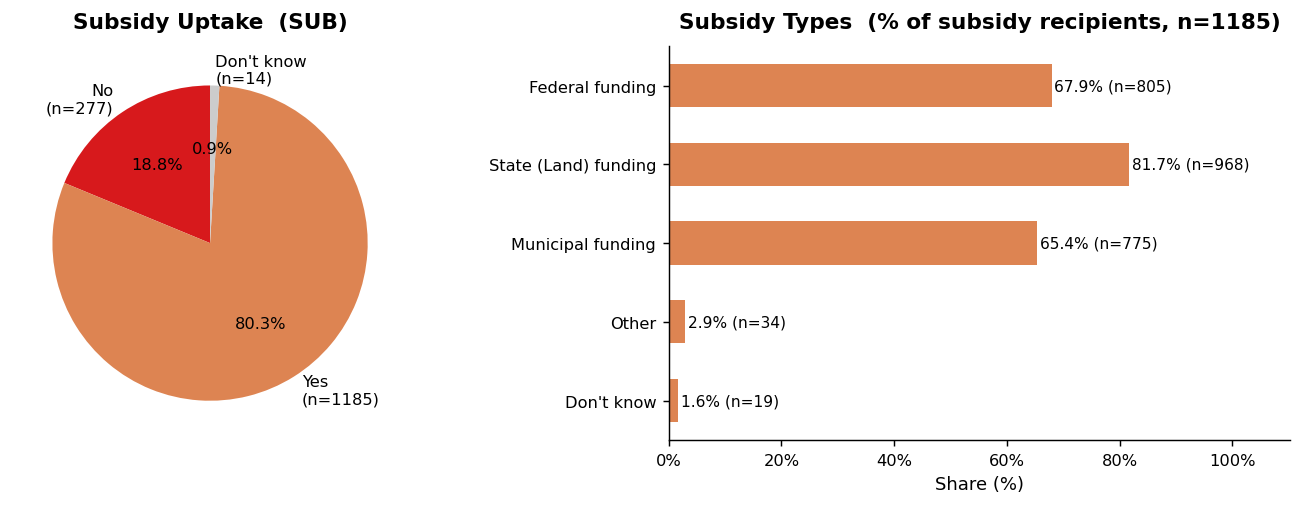

In [8]:
# ── 4b: Subsidy uptake + subsidy types ────────────────────────────────────────
sub_map = {"0": "No", "1": "Yes", "2": "Don't know"}

sub_raw    = Counter(get_field("SUB"))
sub_keys   = sorted(sub_raw, key=int)
sub_vals   = [sub_raw[k] for k in sub_keys]
sub_labels = [f"{sub_map[k]}\n(n={sub_raw[k]})" for k in sub_keys]

type_fields = ["SUB_1", "SUB_2", "SUB_3", "SUB_4", "SUB_5"]
type_labels = ["Federal funding", "State (Land) funding",
               "Municipal funding", "Other", "Don't know"]
type_counts = [sum(1 for r in data if str(r.get(f, '')) == '1') for f in type_fields]
# base = respondents who received a subsidy
sub_yes_n   = sub_raw.get("1", 0)
type_pcts   = [c / sub_yes_n * 100 if sub_yes_n else 0 for c in type_counts]

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Pie — subsidy uptake
axes[0].pie(sub_vals, labels=sub_labels, autopct="%1.1f%%",
            colors=["#d7191c", C_TRIG, "#cccccc"], startangle=90,
            textprops={"fontsize": 9})
axes[0].set_title("Subsidy Uptake  (SUB)", pad=10)

# Bar — subsidy types (among those who received any)
bars = axes[1].barh(type_labels[::-1], type_pcts[::-1], color=C_TRIG, height=0.55)
axes[1].set_title(f"Subsidy Types  (% of subsidy recipients, n={sub_yes_n})", pad=10)
axes[1].set_xlabel("Share (%)")
axes[1].xaxis.set_major_formatter(mtick.PercentFormatter())
for bar, pct, cnt in zip(bars, type_pcts[::-1], type_counts[::-1]):
    axes[1].text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
                 f"{pct:.1f}% (n={cnt})", va="center", fontsize=8.5)
axes[1].set_xlim(0, max(type_pcts) * 1.35)

plt.tight_layout()
plt.show()

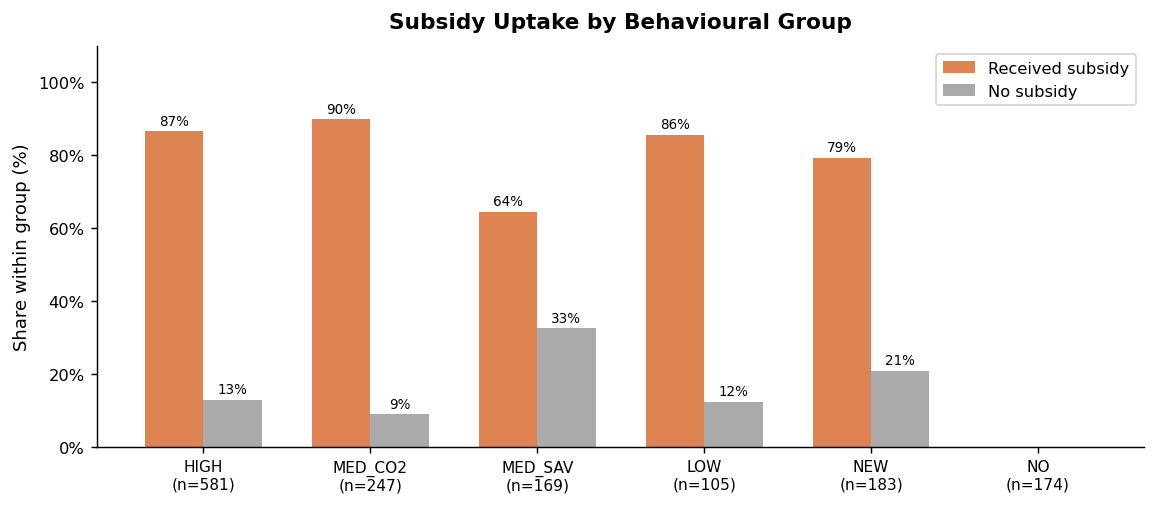

In [ ]:
# ── 4c: Subsidy uptake by behavioural group (grouped bar) ─────────────────────
grp_short = {
    "1": "HIGH", "2": "MED_CO2", "3": "MED_SAV",
    "4": "LOW",  "5": "NEW",     "6": "NO",
}

grp_order = ["1", "2", "3", "4", "5", "6"]
sub_by_grp_yes = []
sub_by_grp_no  = []
grp_ns         = []

for g in grp_order:
    members = [r for r in data if str(r.get("GROUP_BEH", "")) == g]
    n_total = len(members)
    n_yes   = sum(1 for r in members if str(r.get("SUB", "")) == "1")
    n_no    = sum(1 for r in members if str(r.get("SUB", "")) == "0")
    sub_by_grp_yes.append(n_yes / n_total * 100 if n_total else 0)
    sub_by_grp_no.append(n_no  / n_total * 100 if n_total else 0)
    grp_ns.append(n_total)

x     = np.arange(len(grp_order))
w     = 0.35
xlbls = [f"{grp_short[g]}\n(n={grp_ns[i]})" for i, g in enumerate(grp_order)]

fig, ax = plt.subplots(figsize=(9, 4))
bars_yes = ax.bar(x - w/2, sub_by_grp_yes, w, label="Received subsidy", color=C_TRIG)
bars_no  = ax.bar(x + w/2, sub_by_grp_no,  w, label="No subsidy",       color="#aaaaaa")
ax.set_title("Subsidy Uptake by Behavioural Group", pad=10)
ax.set_ylabel("Share within group (%)")
ax.set_xticks(x)
ax.set_xticklabels(xlbls, fontsize=8.5)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_ylim(0, 110)
ax.legend(fontsize=9)
for bar in list(bars_yes) + list(bars_no):
    h = bar.get_height()
    if h > 3:
        ax.text(bar.get_x() + bar.get_width() / 2, h + 1,
                f"{h:.0f}%", ha="center", va="bottom", fontsize=7.5)
plt.tight_layout()
plt.show()